In [1]:
!pip install polars

import polars as pl

In [2]:
import os
import random
import sys
import cv2
import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [1]:

!nvidia-smi

Wed Feb 18 20:12:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               On  |   00000000:D6:00.0 Off |                  Off |
| 36%   64C    P2            179W /  230W |   12129MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
os.chdir('/workspace')

In [5]:
BASE_PATH = 'vindr_mammogram'
IMG_DIR = os.path.join(BASE_PATH, 'mammo_processed_merged1') 
csv_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.csv')]

# Print results
if csv_files:
    print(f"Found {len(csv_files)} CSV file(s) in {IMG_DIR}:")
    for csv_file in csv_files:
        print(f"{csv_file}")
else:
    print(f"No CSV files found in {IMG_DIR}")


Found 1 CSV file(s) in vindr_mammogram/mammo_processed_merged1:
mammo_processed_merged.csv


In [6]:
df = pl.read_csv("vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv")
df = df.to_pandas()
df["merged_image_path"] = (
    df["merged_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
density_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

df['density'] = df['cc_breast_density'].str[-1].map(density_mapping)
df.head()



,study_id,laterality,merged_image_path,cc_image_id,mlo_image_id,split,cc_image_path,mlo_image_path,has_cc_bbox,has_mlo_bbox,...,mlo_crop_coords,cc_breast_birads,mlo_breast_birads,cc_breast_density,mlo_breast_density,cc_finding_categories,mlo_finding_categories,cc_finding_birads,mlo_finding_birads,density
0,0025a5dc99fd5c742026f0b2b030d3e9,L,vindr_mammogram/mammo_processed_merged1/0025a5...,451562831387e2822923204cf8f0873e,2ddfad7286c2b016931ceccd1e2c7bbc,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 992, 2443)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
1,0025a5dc99fd5c742026f0b2b030d3e9,R,vindr_mammogram/mammo_processed_merged1/0025a5...,fcf12c2803ba8dc564bf1287c0c97d9a,47c8858666bcce92bcbd57974b5ce522,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(11, 0, 1064, 2560)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
2,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,L,vindr_mammogram/mammo_processed_merged1/0028fb...,3704f91985dcbc69f6ac2803523d1ecb,7fc1f1bb8bb1a7efaf7104e49c4d8b86,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 935, 2486)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
3,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,R,vindr_mammogram/mammo_processed_merged1/0028fb...,c4ce68631bf70949570ded31a3c69e60,16e58fc1d65fa7587247e6224ee96527,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(13, 0, 953, 2508)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
4,0034765af074f93ed33d5e8399355caf,L,vindr_mammogram/mammo_processed_merged1/003476...,68f09c18925a66ef2840d4a62f237b31,b664cf1e7c968896144a3a2005cd3eb4,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 961, 2802)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2


In [7]:
def get_combined_finding_6class(cc_findings, mlo_findings, cc_birads, mlo_birads):
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    def parse_birads(birads_str):
        if pd.isna(birads_str) or birads_str == '':
            return 0
        if isinstance(birads_str, str):
            try:
                return int(birads_str.strip().split()[-1])
            except:
                return 0
        return int(birads_str)
    
    cc_birads_num = parse_birads(cc_birads)
    mlo_birads_num = parse_birads(mlo_birads)
    max_birads = max(cc_birads_num, mlo_birads_num)
    
    if not all_findings or all_findings == {'No Finding'}:
        if max_birads == 1:
            return 0
        elif max_birads == 2:
            return 1
        else:
            return 1 if max_birads == 3 else 4
    
    if has_structural:
        return 4
    
    if has_mass and has_calc:
        return 3
    
    if has_mass:
        return 3
    
    if has_calc:
        return 2
    
    if has_lymph:
        return 4
    
    if has_asymmetry and len(all_findings) == 1:
        return -1
    
    if has_asymmetry and len(all_findings) > 1:
        return 4
    
    print(f"Warning: Unknown finding combination: {all_findings}, BIRADS: {max_birads}")
    return 4

df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['cc_finding_categories'], 
        row['mlo_finding_categories'],
        row['cc_breast_birads'],
        row['mlo_breast_birads']
    ),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts().sort_index()

finding
0    6703
1    2329
2     132
3     551
4      95
Name: count, dtype: int64

In [8]:
inbreast_df = pd.read_csv("inbreast_data/INbreast_merged/merged_metadata.csv")
inbreast_df["merged_image_path"] = (
    inbreast_df["merged_image_path"]
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False)
    .str.replace("vindr_original_data", "inbreast_data", regex=False))
inbreast_df['birads'] = inbreast_df['birads'].replace({'4a': '4', '4b': '4', '4c': '4','6':'5'})
inbreast_df['birads'] = (inbreast_df['birads'].astype(int) - 1).astype(int)
def birads_to_binary(birads):
    if birads ==0:
        return 0 
    else:
        return 1 
inbreast_df['label'] = inbreast_df['birads'].apply(birads_to_binary)
inbreast_df['density'] = 0
inbreast_df.head()

,patient_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label,density
0,024ee3569b2605dc,L,inbreast_data/INbreast_merged/024ee3569b2605dc...,20588020,20588072,INbreast Release 1.0/INbreast_processed/205880...,INbreast Release 1.0/INbreast_processed/205880...,1,1557,3231,1674,3192,1,0
1,024ee3569b2605dc,R,inbreast_data/INbreast_merged/024ee3569b2605dc...,20587994,20588046,INbreast Release 1.0/INbreast_processed/205879...,INbreast Release 1.0/INbreast_processed/205880...,4,1535,3128,1775,3199,1,0
2,069212ec65a94339,L,inbreast_data/INbreast_merged/069212ec65a94339...,50994787,50994733,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,0,1226,2580,1340,3193,0,0
3,069212ec65a94339,R,inbreast_data/INbreast_merged/069212ec65a94339...,50994706,50994760,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,0,1128,2566,1177,3195,0,0
4,0b7396cdccacca82,L,inbreast_data/INbreast_merged/0b7396cdccacca82...,22670832,22670878,INbreast Release 1.0/INbreast_processed/226708...,INbreast Release 1.0/INbreast_processed/226708...,1,1627,2983,1598,3170,1,0


In [9]:
def birads_to_label(birads_category):
    """Convert BI-RADS categories to numerical labels 0-4 (for 5 classes)"""
    birads_num = int(birads_category.replace(" ", "")[-1])
    return birads_num - 1
df['birads'] = df['cc_breast_birads'].apply(birads_to_label)

In [10]:
def birads_to_binary(birads):
    return 0 if birads in ['BI-RADS 1'] else 1 
df['label'] = df['cc_breast_birads'].apply(birads_to_binary)

In [11]:
df['cc_breast_birads'].value_counts()

cc_breast_birads
BI-RADS 1    6703
BI-RADS 2    2337
BI-RADS 4     339
BI-RADS 3     319
BI-RADS 5     112
Name: count, dtype: int64

In [12]:
df['cc_breast_density'].value_counts()

cc_breast_density
DENSITY C    7486
DENSITY D    1335
DENSITY B     942
DENSITY A      47
Name: count, dtype: int64

In [13]:
data = df[df['split'] == 'training']
test_df = df[df['split'] == 'test']

In [14]:
from sklearn.model_selection import train_test_split


study_meta = (
    data
    .groupby('study_id')
    .agg({
        'cc_breast_birads': 'first',   # BI-RADS at study level
        'finding': 'first'             # finding already encoded as 0–4
    })
    .reset_index()
)


# -------------------------------------------------
study_meta['stratify_key'] = (
    study_meta['cc_breast_birads'].astype(str) + '_' +
    study_meta['finding'].astype(str)
)


train_studies, val_studies = train_test_split(
    study_meta['study_id'],
    test_size=0.1,
    stratify=study_meta['stratify_key'],
    random_state=423
)

train_df = data[data['study_id'].isin(train_studies)].copy()
val_df   = data[data['study_id'].isin(val_studies)].copy()


In [15]:
train_df['density'].value_counts()

density
2    5394
3     963
1     668
0      32
Name: count, dtype: int64

In [16]:
val_df['density'].value_counts()

density
2    591
3    105
1     86
0      5
Name: count, dtype: int64

In [17]:
train_df.shape

(7057, 28)

In [18]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=10,
                translate=(0.05, 0.05),
                scale=(0.9, 1.1),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomApply([
            transforms.RandomPerspective(distortion_scale=0.1, p=1.0)
        ], p=0.1),
        
        transforms.RandomApply([
            transforms.ElasticTransform(alpha=20.0, sigma=3.0)
        ], p=0.2),
        
        transforms.RandomApply([
            transforms.RandomChoice([
                transforms.ColorJitter(
                    brightness=(0.95, 1.05),
                    contrast=(0.9, 1.1)
                ),
                transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.1)))
            ])
        ], p=0.5),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def add_speckle_noise(image, std=0.03):
    """Speckle noise - multiplicative noise common in mammography"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, std, img_array.shape)
        noisy_img = img_array + img_array * noise
        return Image.fromarray((np.clip(noisy_img, 0, 1) * 255).astype(np.uint8))
    return image

def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [19]:
# def get_transforms(img_size=(512, 512)):

#     train_light = transforms.Compose([
#         transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),

#         transforms.RandomApply([
#             transforms.RandomAffine(
#                 degrees=8,
#                 translate=(0.1, 0.1),
#                 scale=(0.90, 1.10),
#                 shear=2
#             )
#         ], p=0.3),

#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.RandomVerticalFlip(p=0.15),

#         transforms.RandomApply([
#             transforms.ColorJitter(
#                 brightness=(0.8, 1.2),
#                 contrast=(0.8, 1.2)
#             )
#         ], p=0.3),

#         transforms.Lambda(
#             lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2))
#         ),

#         transforms.Lambda(
#             lambda x: add_gaussian_noise(
#                 x, mean=0, std=random.uniform(0.005, 0.01)
#             )
#         ),

#         transforms.Lambda(
#             lambda x: add_speckle_noise(
#                 x, std=random.uniform(0.005, 0.015)
#             )
#         ),

#         transforms.ToTensor(),
#         transforms.Normalize(
#             mean=[0.485, 0.456, 0.406],
#             std=[0.229, 0.224, 0.225]
#         )
#     ])


#     train_malignant = transforms.Compose([
#         transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),

#         transforms.RandomApply([
#             transforms.RandomAffine(
#                 degrees=5,                 # SMALL rotation
#                 translate=(0.05, 0.05),
#                 scale=(0.95, 1.05),
#                 shear=2
#             )
#         ], p=0.25),

#         transforms.RandomHorizontalFlip(p=0.5),

#         transforms.RandomApply([
#             transforms.ColorJitter(
#                 brightness=(0.9, 1.1),
#                 contrast=(0.9, 1.1)
#             )
#         ], p=0.5),

#         transforms.Lambda(
#             lambda x: adjust_gamma(x, gamma=random.uniform(0.9, 1.1))
#         ),

#         transforms.Lambda(
#             lambda x: add_gaussian_noise(
#                 x, mean=0, std=random.uniform(0.005, 0.01)
#             )
#         ),

#         transforms.ToTensor(),
#         transforms.Normalize(
#             mean=[0.485, 0.456, 0.406],
#             std=[0.229, 0.224, 0.225]
#         )
#     ])


#     val_transform = transforms.Compose([
#         transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
#         transforms.ToTensor(),
#         transforms.Normalize(
#             mean=[0.485, 0.456, 0.406],
#             std=[0.229, 0.224, 0.225]
#         )
#     ])

#     return train_light, train_malignant, val_transform


In [20]:
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
import random


class VinDrMammoDataset(Dataset):
    def __init__(self, dataframe, train_light, val_transform, mode="train"):
        self.df = dataframe.reset_index(drop=True)
        self.train_light = train_light
        self.val_transform = val_transform
        self.mode = mode

        counts = self.df["label"].value_counts().to_dict()
        print(f"{mode.upper()} class distribution:", counts)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["merged_image_path"]).convert("RGB")
        label = int(row["label"])

        birads=row['birads']
        if self.mode == "train":
            image_tensor = self.train_light(image)
        else:
            image_tensor = self.val_transform(image)
            
        density = row['density'] if 'density' in row else 0 
        density_tensor = torch.tensor(density, dtype=torch.long)
        return row["merged_image_path"], image_tensor, torch.tensor(label, dtype=torch.long),density_tensor

def create_data_loaders(train_df, val, test_df, inbreast_df, batch_size=8, img_size=(512, 512)):
    """Create train and val dataloaders with weighted sampling"""
    train_light, val_transform = get_transforms(img_size)

    train_dataset = VinDrMammoDataset(
        train_df, train_light, val_transform, mode="train"
    )
    val_dataset = VinDrMammoDataset(
        val_df, train_light, val_transform, mode="val"
    )
    test_dataset = VinDrMammoDataset(
        test_df, train_light, val_transform, mode="val"
    )
    inbreast_dataset = VinDrMammoDataset(
        inbreast_df, train_light,val_transform, mode="val"
    )
    # labels = train_df['label'].values 
    # sampler = MajorityUnderSampler(labels, target_ratio=1.0).get_sampler()  # 1:1 balance
    
    labels = train_df['label'].values
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    
    β = 0.5 # 0.5–0.8 typical; 1.0 means full inverse, 0.0 means no balancing
    class_weights = (1.0 / class_counts) ** β
    class_weights = class_weights / class_weights.sum() * len(unique_classes)
    
    sample_weights = class_weights[labels]
    print("Class counts:", dict(zip(unique_classes, class_counts)))
    print("Smoothed class weights:", np.round(class_weights, 3))
    
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        # shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True  
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    inbreast_loader = DataLoader(
        inbreast_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    return train_loader, val_loader,test_loader,inbreast_loader

batch_size=4
train_loader,val_loader,test_loader,inbreast_loader = create_data_loaders(
    train_df,val_df, test_df, inbreast_df,
    batch_size=batch_size,
    img_size=(1024, 1024)
)

TRAIN class distribution: {0: 4823, 1: 2234}
VAL class distribution: {0: 539, 1: 248}
VAL class distribution: {0: 1341, 1: 625}
VAL class distribution: {1: 157, 0: 30}
Class counts: {np.int64(0): np.int64(4823), np.int64(1): np.int64(2234)}
Smoothed class weights: [0.81 1.19]


Visualizing training samples:


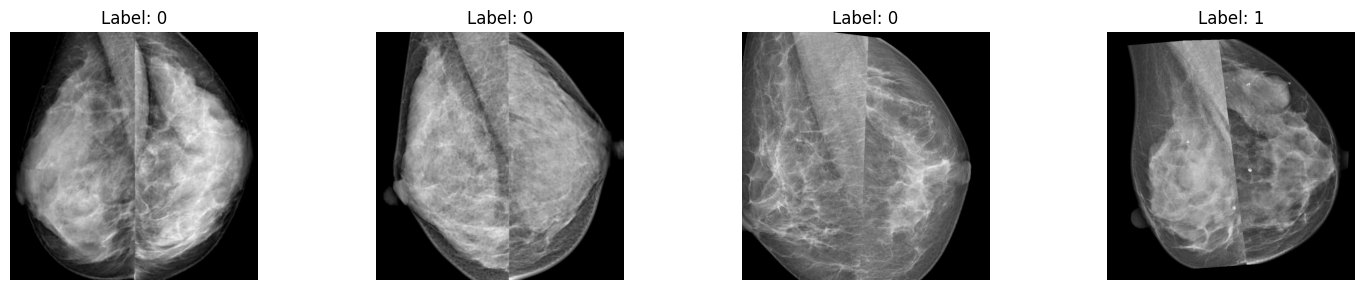


Visualizing validation samples:


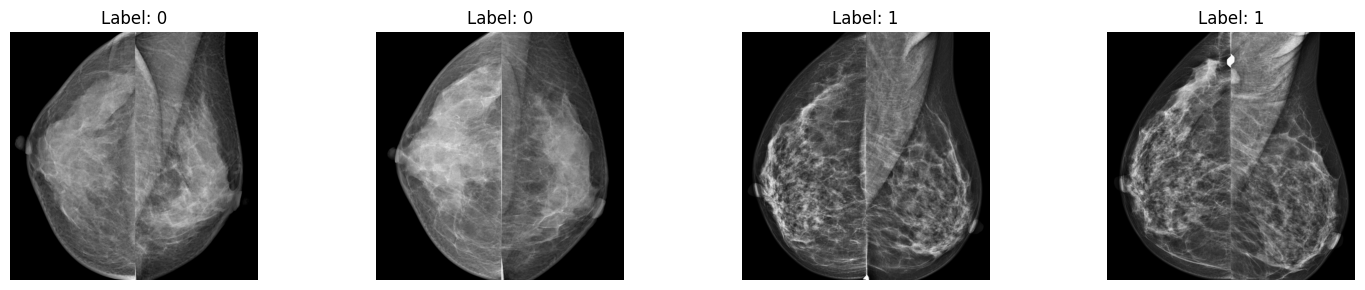

In [21]:
def visualize_batch(batch, n_cols=4, apply_inverse_normalize=True):
    """Visualize a batch of images with their labels"""
    _,images, labels,_ = batch
    batch_size = images.shape[0]
    n_rows = int(np.ceil(batch_size / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(batch_size):
        img = images[i]
        label = labels[i].item()
        
        # Inverse normalization if needed
        if apply_inverse_normalize:
            img = img.permute(1, 2, 0).numpy()
            # img=img*255
            img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255
            img = img.mean(axis=2).astype(np.uint8)
        else:
            img = img.permute(1, 2, 0).numpy().astype(np.uint8)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize samples
print("Visualizing training samples:")
# Get a batch
train_batch = next(iter(train_loader))
visualize_batch(train_batch)

print("\nVisualizing validation samples:")
val_batch = next(iter(val_loader))
visualize_batch(val_batch)

In [22]:

from tqdm import tqdm
import torch.nn as nn
from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, classification_report

In [23]:

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (image_path,images, labels,density) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)  # Using CrossEntropyLoss (or custom BI_RADS_Loss)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)  # Predicted class indices
        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx}")
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Multi-class metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')  # or 'macro'
    cls_report = classification_report(
        all_labels, 
        all_preds, 
        target_names=['Benign', 'Malignant'],
        digits=4
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss, accuracy, f1, cls_report, conf_matrix

def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for image_path,images, labels,density in data_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Multi-class metrics
    accuracy = accuracy_score(all_labels, all_preds)
    malignant_recall = recall_score(all_labels, all_preds, pos_label=1)
    f1 = f1_score(all_labels, all_preds, average='macro')  # or 'macro',weighted
    f1_pos = f1_score(all_labels, all_preds, average='binary', pos_label=1)
    cls_report = classification_report(
        all_labels, 
        all_preds, 
        target_names=['Benign','Malignant'],  # Update class names
        digits=4
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    avg_loss = total_loss / len(data_loader)
    return avg_loss, accuracy, f1,f1_pos, cls_report, conf_matrix,malignant_recall


In [24]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score
import pandas as pd
import numpy as np
import torch

# ============================================================
# TRAIN FUNCTION (with density report)
# ============================================================

def train_epoch(model, train_loader, optimizer, device, accumulation_steps=4):
    model.train()
    total_loss = 0
    all_preds, all_labels, all_densities = [], [], []
    
    optimizer.zero_grad()  # Important: zero once at the start when using accumulation
    
    for batch_idx, (image_path, images, labels, density) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps               # Scale loss to keep average correct
        loss.backward()
        
        # Perform optimizer step every `accumulation_steps` batches
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()                      # Reset gradients after update
        
        total_loss += loss.item() * accumulation_steps  # Un-scale for reporting
        
        preds = torch.argmax(outputs, dim=1)
        
        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx} | Loss: {loss.item() * accumulation_steps:.4f}")
        
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_densities.append(density.cpu())
    
    # Final step if dataset size is not divisible by accumulation_steps
    if len(train_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

    # Concatenate all predictions/labels
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_densities = torch.cat(all_densities).numpy()

    # Overall metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    cls_report = classification_report(all_labels, all_preds,
                                       target_names=['Benign', 'Malignant'],
                                       digits=4)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)

    # --- Density-wise report ---
    density_report = []
    for d in np.unique(all_densities):
        mask = all_densities == d
        if mask.sum() > 0:
            acc_d = accuracy_score(all_labels[mask], all_preds[mask])
            rec_d = recall_score(all_labels[mask], all_preds[mask], pos_label=1, zero_division=0)
            f1_d = f1_score(all_labels[mask], all_preds[mask], average='binary', pos_label=1, zero_division=0)
            density_report.append({
                "Density": int(d),
                "Samples": int(mask.sum()),
                "Accuracy": round(acc_d, 4),
                "Recall_Pos": round(rec_d, 4),
                "F1_Pos": round(f1_d, 4)
            })
    density_df = pd.DataFrame(density_report)

    return avg_loss, accuracy, f1, cls_report, conf_matrix, density_df


# ============================================================
# EVALUATION FUNCTION (with density report)
# ============================================================
@torch.inference_mode()
def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_densities = [], [], []

    with torch.no_grad():
        for image_path, images, labels, density in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_densities.append(density.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_densities = torch.cat(all_densities).numpy()

    # Overall metrics
    accuracy = accuracy_score(all_labels, all_preds)
    malignant_recall = recall_score(all_labels, all_preds, pos_label=1)
    f1 = f1_score(all_labels, all_preds, average='macro')
    f1_pos = f1_score(all_labels, all_preds, average='binary', pos_label=1)
    cls_report = classification_report(all_labels, all_preds,
                                       target_names=['Benign', 'Malignant'],
                                       digits=4)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(data_loader)

    # --- Density-wise report ---
    density_report = []
    for d in np.unique(all_densities):
        mask = all_densities == d
        if mask.sum() > 0:
            acc_d = accuracy_score(all_labels[mask], all_preds[mask])
            rec_d = recall_score(all_labels[mask], all_preds[mask], pos_label=1)
            f1_d = f1_score(all_labels[mask], all_preds[mask], average='binary', pos_label=1)
            density_report.append({
                "Density": int(d),
                "Samples": int(mask.sum()),
                "Accuracy": round(acc_d, 4),
                "Recall_Pos": round(rec_d, 4),
                "F1_Pos": round(f1_d, 4)
            })

    density_df = pd.DataFrame(density_report)

    # Return all original + density report at the end
    return avg_loss, accuracy, f1, f1_pos, cls_report, conf_matrix, malignant_recall, density_df


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
def test_and_save_results(model, test_loader, device, model_name, dataset_name, save_dir):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        for image_path, images, labels,density in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_pos = f1_score(all_labels, all_preds, average='binary', pos_label=1)
    recall_pos = recall_score(all_labels, all_preds, pos_label=1)
    cls_report = classification_report(all_labels, all_preds, target_names=['Benign','Malignant'], digits=4)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(test_loader)

    # ---- Save Confusion Matrix ----
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {dataset_name} ({model_name})')
    plt.tight_layout()
    cm_path = os.path.join(save_dir, f'{dataset_name}_confusion_matrix.png')
    plt.savefig(cm_path)
    plt.close()

    results_path = os.path.join(save_dir, f'{dataset_name}_results.txt')
    with open(results_path, 'w') as f:
        f.write(f'Model: {model_name}\n')
        f.write(f'Dataset: {dataset_name}\n')
        f.write(f'Loss: {avg_loss:.4f}\n')
        f.write(f'Accuracy: {accuracy:.4f}\n')
        f.write(f'F1 (macro): {f1_macro:.4f}\n')
        f.write(f'F1 (malignant): {f1_pos:.4f}\n')
        f.write(f'Recall (malignant): {recall_pos:.4f}\n')
        f.write('\nClassification Report:\n')
        f.write(cls_report)
    print(f"Results saved to {save_dir}")

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_pos': f1_pos,
        'recall_pos': recall_pos,
        'conf_matrix': conf_matrix,
        'cls_report': cls_report
    }


In [26]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.7, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import AdamW
import time
import os
import gc
from torch.optim.lr_scheduler import SequentialLR, CosineAnnealingLR, ReduceLROnPlateau
from torchvision import models

class AsymmetricFocalLoss(nn.Module):

    def __init__(self, gamma_neg=1.0, gamma_pos=2.0, alpha=0.75, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg  # Gamma for negative class (benign)
        self.gamma_pos = gamma_pos  # Gamma for positive class (malignant)
        self.alpha = alpha          # Class weight (0.75 means 75% weight to malignant)
        self.eps = eps
    
    def forward(self, logits, targets):
        """
        Args:
            logits: [batch_size, 2]
            targets: [batch_size] - 0=Benign, 1=Malignant
        """
        # Standard cross-entropy
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        
        # Get predicted probability for true class
        pt = torch.exp(-ce_loss)
        
        # Determine gamma and alpha for each sample
        gamma = torch.where(targets == 1, 
                           torch.tensor(self.gamma_pos, device=logits.device),
                           torch.tensor(self.gamma_neg, device=logits.device))
        
        alpha_t = torch.where(targets == 1,
                             torch.tensor(self.alpha, device=logits.device),
                             torch.tensor(1 - self.alpha, device=logits.device))
        
        # Focal loss
        focal_loss = alpha_t * (1 - pt) ** gamma * ce_loss
        
        return focal_loss.mean()
        
criterion = AsymmetricFocalLoss(
    gamma_neg=2.0,
    gamma_pos=1.0,
    alpha=0.6
)


models_config = [
    {
        'name': 'efficientnet_b3',
        'class': models.efficientnet_b3,
        'weights': models.EfficientNet_B3_Weights.DEFAULT
    },

    {
        'name': 'convnext_base',
        'class': models.convnext_base,
        'weights': models.ConvNeXt_Base_Weights.DEFAULT
    },

    # {
    #     'name': 'swin_v2_b',
    #     'class': models.swin_v2_b,
    #     'weights': models.Swin_V2_B_Weights.DEFAULT
    # },
]


class GenericNet(nn.Module):

    def __init__(self, backbone_name, backbone_class, backbone_weights):
        super().__init__()
        self.num_classes = 2  
        self.backbone_name = backbone_name
        
        # Load pretrained backbone
        self.backbone = backbone_class(weights=backbone_weights)
        
        # Extract feature size and remove original classifier
        if 'efficientnet' in backbone_name:
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'resnet' in backbone_name:
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        elif 'densenet' in backbone_name:
            num_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'convnext' in backbone_name:
            num_features = self.backbone.classifier[2].in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'swin' in backbone_name:
            num_features = self.backbone.head.in_features
            self.backbone.head = nn.Identity()
        
        else:
            raise ValueError(f"Unsupported model type: {backbone_name}")
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        hidden_size = 768 if 'swin' in backbone_name else 512
        
        # Unified classification head
        self.classifier = nn.Sequential(
            nn.Linear(num_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes)
        )

    def forward(self, x):
        """
        Forward pass
        Args:
            x: [batch_size, 3, 512, 512] input images
        Returns:
            logits: [batch_size, 3] class logits
        """
        features = self.backbone(x)
        
        # Handle different output formats
        if isinstance(features, tuple):
            features = features[0]
        
        # If spatial dimensions exist, apply global pooling
        if features.ndim == 4:  # [B, C, H, W]
            features = self.global_pool(features).flatten(1)
        
        # Classification
        logits = self.classifier(features)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False
        else:
            self.best_score = score
            self.counter = 0
            return False

# Main training loop for all models
for model_config in models_config:
    model_name = model_config['name']
    print(f"\n{'='*80}")
    print(f"Training {model_name}")
    print(f"{'='*80}")
    
    # Initialize model
    model = GenericNet(
        model_name,
        model_config['class'],
        model_config['weights']
    ).to(device)
    
    optimizer = AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 5e-5}
], weight_decay=0.01)
    
    plateau_scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.3,  
        patience=12,  
        min_lr=1e-6
    )
    early_stopper = EarlyStopper(patience=20)
    
    # Create output directory for this model
    output_dir = f'Thesis_updated_results/Merged_binary_1024/{model_name}'
    os.makedirs(output_dir, exist_ok=True)
    best_model_path = os.path.join(output_dir, 'best_model.pth')
    
    best_val_f1 = 0.0
    best_f1_pos = 0.0
    epochs = 60
    
    print('=============================================================')
    print(f'Training {model_name}...')
    
    # for epoch in range(epochs):
    #     start_time = time.time()
        
    #     model.train()
    #     train_loss, train_acc, train_f1, train_report, conf_matrix_train,train_density = train_epoch(model, train_loader, optimizer, device)
        
    #     val_loss, val_acc, val_f1, f1_pos, val_report, conf_matrix_val, malignant_recall,val_density = evaluate(model, val_loader, device)
    #     if epoch < 25:
    #         plateau_scheduler.step(val_f1)
    #     else:
    #         plateau_scheduler.step(f1_pos)
        
    #     if early_stopper(val_f1):
    #         print(f"Early stopping triggered at epoch {epoch+1}!")
    #         break
            
    #     if val_f1 > best_val_f1:
    #         best_val_f1 = val_f1
    #         best_f1_pos = f1_pos
    #         torch.save(model.state_dict(), best_model_path)
    #         print(f"New best model saved with val_f1={val_f1:.4f}")
        
    #     epoch_time = time.time() - start_time
    #     current_lr = optimizer.param_groups[0]['lr']
    #     print(f"\nEpoch {epoch+1}/{epochs} - {epoch_time:.1f}s")
    #     print(f"LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    #     print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
    #     print("\nTrain Report:")
    #     print(train_report)
    #     print("\nTrain CM:")
    #     print(conf_matrix_train)
    #     print("\nTrain density:")
    #     print(train_density)
    #     print("\nVal Report:")
    #     print(val_report)
    #     print("\nVal CM:")
    #     print(conf_matrix_val)
    #     print("\nval density:")
    #     print(val_density)
    #     print('-' * 50)
    
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)
    model.eval()
    
    print(f"\n{'='*80}")
    print(f"Testing {model_name} on VinDr Test and INbreast datasets...")
    print(f"{'='*80}")
    
    # Paths to save
    vindr_save_dir = f"{output_dir}/vindr_test"
    inbreast_save_dir = f"{output_dir}/inbreast_test"
    
    vindr_val = test_and_save_results(
        model, val_loader, device, model_name, 'validation', vindr_save_dir
    )
    vindr_results = test_and_save_results(
        model, test_loader, device, model_name, 'VinDr-Mammo', vindr_save_dir
    )

    inbreast_results = test_and_save_results(
        model, inbreast_loader, device, model_name, 'INbreast', inbreast_save_dir
    )
    
    print("\nVinDr-Mammo Test Results:")
    print(vindr_results['cls_report'])
    print("\nINbreast Test Results:")
    print(inbreast_results['cls_report'])
    del model, optimizer, plateau_scheduler
    torch.cuda.empty_cache()
    gc.collect()


Training efficientnet_b3
Training efficientnet_b3...

Testing efficientnet_b3 on VinDr Test and INbreast datasets...
Results saved to Thesis_updated_results/Merged_binary_1024/efficientnet_b3/vindr_test
